In [137]:
import pandas as pd

file_name = "3d7096dc"
csv_path = "../data/csv/" + file_name + ".csv"
df = pd.read_csv(csv_path)
df

,img,wheel-axis,clutch,brake,gas,paddle-left,paddle-right,wheel-button-left-1,wheel-button-left-2,wheel-button-left-3,...,shifter-button-2,shifter-button-3,shifter-button-4,gear-1,gear-2,gear-3,gear-4,gear-5,gear-6,gear-R
0,3d7096dc_2022_12_01_14_33_01_63.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3d7096dc_2022_12_01_14_33_01_66.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3d7096dc_2022_12_01_14_33_01_70.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3d7096dc_2022_12_01_14_33_01_74.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3d7096dc_2022_12_01_14_33_01_77.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5140,3d7096dc_2022_12_01_14_37_07_48.jpg,6213,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5141,3d7096dc_2022_12_01_14_37_07_52.jpg,6298,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5142,3d7096dc_2022_12_01_14_37_07_56.jpg,6383,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5143,3d7096dc_2022_12_01_14_37_07_60.jpg,6468,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [138]:
import os
def make_dir(path: str):
    if not os.path.exists(path):
        os.makedirs(path)

image size is (1152, 864)


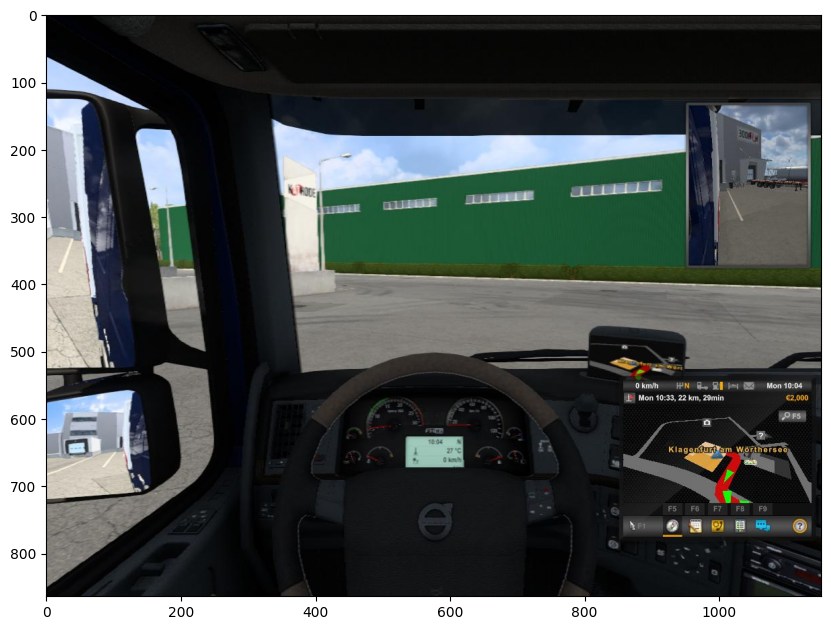

In [139]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

img_base_path = "../data/img"
img_dir_path = os.path.join(img_base_path, "raw")
img_front_dir_path = os.path.join(img_base_path, 'front')
img_left_dir_path = os.path.join(img_base_path, 'side_left')
img_right_dir_path = os.path.join(img_base_path, 'side_right')
make_dir(img_front_dir_path)
make_dir(img_left_dir_path)
make_dir(img_right_dir_path)
img_path = os.path.join(img_dir_path, df['img'][0])
img = Image.open(img_path)
print("image size is %s" % (img.size,))

fig = plt.figure(figsize = (10,10))
plt.imshow(img)

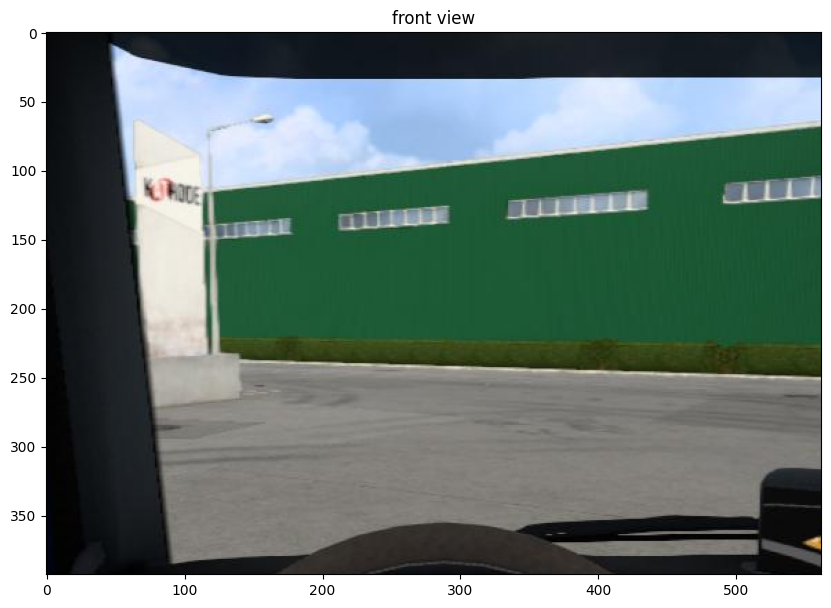

In [140]:
# crop front image
front_coord = (289,147, 851, 540)
img_front = img.crop(front_coord)
fig, ax = plt.subplots(figsize=(10, 10))
ax.set(title='front view')
ax.imshow(img_front)

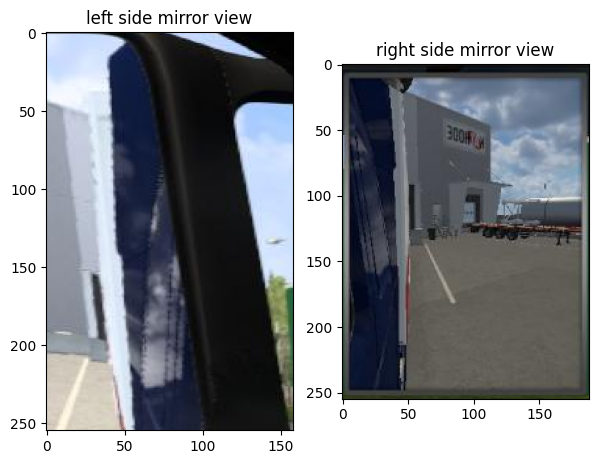

In [141]:
# crop left & right
left_coord = (13, 125, 171, 380)
right_coord = (950, 125, 1138, 380)
img_left = img.crop(left_coord)
img_right = img.crop(right_coord)
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(7,7))
ax0.set(title='left side mirror view')
ax0.imshow(img_left)
ax1.set(title='right side mirror view')
ax1.imshow(img_right)

In [142]:
# save cropped image
def rename_file(f, s):
    return f.split('.')[0] + s + '.' + f.split('.')[1]

img_front_path_list = []
img_left_path_list = []
img_right_path_list = []

for img_filename in df['img']:
    img_path = os.path.join(img_dir_path, img_filename)
    img = Image.open(img_path)
    
    img_front = img.crop(front_coord)
    img_left = img.crop(left_coord)
    img_right = img.crop(right_coord)
    
    img_front_path = rename_file(img_filename, '_front')
    img_left_path = rename_file(img_filename, '_left')
    img_right_path = rename_file(img_filename, '_right')
    
    img_front_path_list.append(img_front_path)
    img_left_path_list.append(img_left_path)
    img_right_path_list.append(img_right_path)
    
    img_front.save(os.path.join(img_front_dir_path, img_front_path))
    img_left.save(os.path.join(img_left_dir_path, img_left_path))
    img_right.save(os.path.join(img_right_dir_path, img_right_path))

In [ ]:
# save new images path
df['front'] = img_front_path_list
df['side_left'] = img_left_path_list
df['side_right'] = img_right_path_list
df.head()

,img,wheel-axis,clutch,brake,gas,paddle-left,paddle-right,wheel-button-left-1,wheel-button-left-2,wheel-button-left-3,...,gear-1,gear-2,gear-3,gear-4,gear-5,gear-6,gear-R,front,side_left,side_right
0,63ac88ec_2023_01_19_13_27_01_14.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,63ac88ec_2023_01_19_13_27_01_14_front.jpg,63ac88ec_2023_01_19_13_27_01_14_left.jpg,63ac88ec_2023_01_19_13_27_01_14_right.jpg
1,63ac88ec_2023_01_19_13_27_01_17.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,63ac88ec_2023_01_19_13_27_01_17_front.jpg,63ac88ec_2023_01_19_13_27_01_17_left.jpg,63ac88ec_2023_01_19_13_27_01_17_right.jpg
2,63ac88ec_2023_01_19_13_27_01_21.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,63ac88ec_2023_01_19_13_27_01_21_front.jpg,63ac88ec_2023_01_19_13_27_01_21_left.jpg,63ac88ec_2023_01_19_13_27_01_21_right.jpg
3,63ac88ec_2023_01_19_13_27_01_26.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,63ac88ec_2023_01_19_13_27_01_26_front.jpg,63ac88ec_2023_01_19_13_27_01_26_left.jpg,63ac88ec_2023_01_19_13_27_01_26_right.jpg
4,63ac88ec_2023_01_19_13_27_01_29.jpg,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,63ac88ec_2023_01_19_13_27_01_29_front.jpg,63ac88ec_2023_01_19_13_27_01_29_left.jpg,63ac88ec_2023_01_19_13_27_01_29_right.jpg


In [ ]:
if not os.path.exists("../data/csv/process"):
    os.makedirs("../data/csv/process")
processed_csv_path = "../data/csv/process/" + file_name + ".csv"
df.to_csv(processed_csv_path, index=False)